In [1]:
#Import Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from google.colab import auth
from googleapiclient.discovery import build

# Authenticate and build Google Drive API service
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Public Google Drive folder and file name
folder_id = "1XkRUF4MCrgqzis3v2C7Bx9GQaK5XgFZI"
file_name = "clean_test.csv"

# Search for the file
results = drive_service.files().list(q=f"'{folder_id}' in parents and name='{file_name}'",
                                     fields="files(id)").execute()
files = results.get("files", [])

if files:
    clean_test = pd.read_csv(f"https://drive.google.com/uc?id={files[0]['id']}")
    print(clean_test)
else:
    print(f"'{file_name}' not found in the folder.")

       Customer_ID outlet_city  luxury_sales  fresh_sales  dry_sales  \
0            33574  Batticaloa       2686.50      3582.00   12537.00   
1            10089  Batticaloa       1717.56      2576.34    9446.58   
2            38329  Batticaloa        854.04      1242.24    5201.88   
3            11376  Batticaloa       1638.12      2320.67    9282.68   
4            12410  Batticaloa       1039.09      1518.67    5435.24   
...            ...         ...           ...          ...        ...   
40744        33698     Wattala       3916.48      4161.26    3916.48   
40745         4185     Wattala       3191.92      3004.16    3098.04   
40746        28664     Wattala       3838.60      3951.50    3700.00   
40747        11874     Wattala       4313.76      4183.04    4313.76   
40748        11431     Wattala       4212.16      4212.16    4212.16   

       outlet_city_encoded  
0                        1  
1                        1  
2                        1  
3                  

In [5]:
from sklearn.preprocessing import RobustScaler
# Identify numerical columns
numerical_columns = ['luxury_sales', 'fresh_sales', 'dry_sales']

# Initialize RobustScaler
DSPL_scaler = RobustScaler()

# Fit on training numerical data and transform both train & test
clean_test[numerical_columns] = DSPL_scaler.fit_transform(clean_test[numerical_columns])
clean_test

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,33574,Batticaloa,0.857034,0.041937,1.631090,1
1,10089,Batticaloa,-0.003695,-0.156121,1.057081,1
2,38329,Batticaloa,-0.770778,-0.418864,0.268678,1
3,11376,Batticaloa,-0.074264,-0.206474,1.026639,1
4,12410,Batticaloa,-0.606394,-0.364423,0.312022,1
...,...,...,...,...,...,...
40744,33698,Wattala,1.949650,0.156019,0.029930,21
40745,4185,Wattala,1.306009,-0.071865,-0.122086,21
40746,28664,Wattala,1.880468,0.114708,-0.010279,21
40747,11874,Wattala,2.302562,0.160308,0.103720,21


In [6]:
import pickle
# Load the model
with open('random_forest_model.sav', 'rb') as file:
    rf_model = pickle.load(file)

In [25]:
# Predict the customer segment
predictors = ['luxury_sales', 'fresh_sales', 'dry_sales','outlet_city_encoded']
clean_test['predicted_customer_segment'] = rf_model.predict(clean_test[predictors])
clean_test

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded,predicted_customer_segment
0,33574,Batticaloa,2686.50,3582.00,12537.00,1,3
1,10089,Batticaloa,1717.56,2576.34,9446.58,1,3
2,38329,Batticaloa,854.04,1242.24,5201.88,1,3
3,11376,Batticaloa,1638.12,2320.67,9282.68,1,3
4,12410,Batticaloa,1039.09,1518.67,5435.24,1,3
...,...,...,...,...,...,...,...
40744,33698,Wattala,3916.48,4161.26,3916.48,21,5
40745,4185,Wattala,3191.92,3004.16,3098.04,21,5
40746,28664,Wattala,3838.60,3951.50,3700.00,21,5
40747,11874,Wattala,4313.76,4183.04,4313.76,21,5


In [10]:
Final_Analytical_Solution = clean_test[['Customer_ID','predicted_customer_segment']]
Final_Analytical_Solution

,Customer_ID,predicted_customer_segment
0,33574,1
1,10089,1
2,38329,1
3,11376,1
4,12410,1
...,...,...
40744,33698,5
40745,4185,5
40746,28664,5
40747,11874,5


In [12]:
Final_Analytical_Solution.to_csv('Analytical_Solution.csv', index=False)

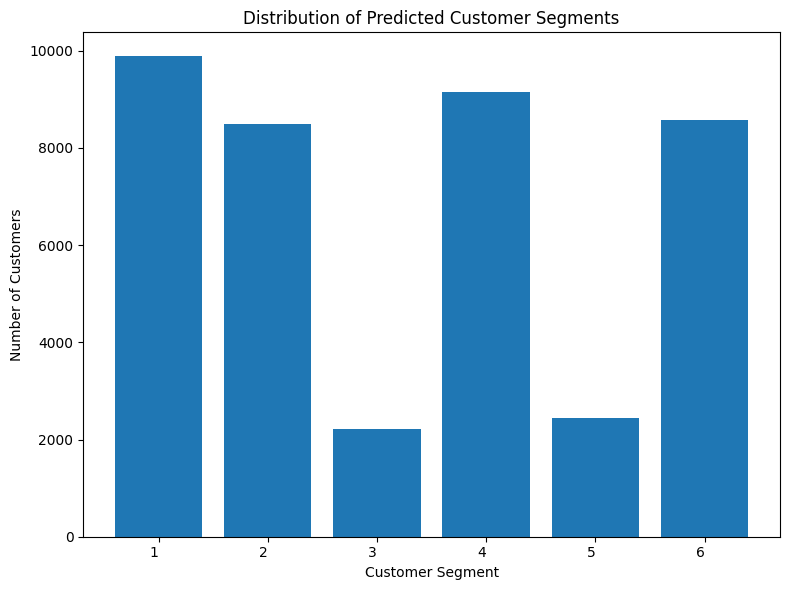

In [16]:
segment_counts = Final_Analytical_Solution['predicted_customer_segment'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Distribution of Predicted Customer Segments")
plt.xticks(ha='right')
plt.tight_layout()
plt.show()


In [21]:
import plotly.express as px
fig = px.scatter_3d(
    clean_test,
    x='luxury_sales',
    y='fresh_sales',
    z='dry_sales',
    color='predicted_customer_segment',
    title="3D Scatter Plot of Customer Segments",
    labels={'luxury_sales': 'Luxury Sales', 'fresh_sales': 'Fresh Sales', 'dry_sales': 'Dry Sales'}
)

fig.show()